<a href="https://colab.research.google.com/github/jaydeep12b/Major-Project-II/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GOOGLE DATSET USE

/tmp/ipython-input-1617608561.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


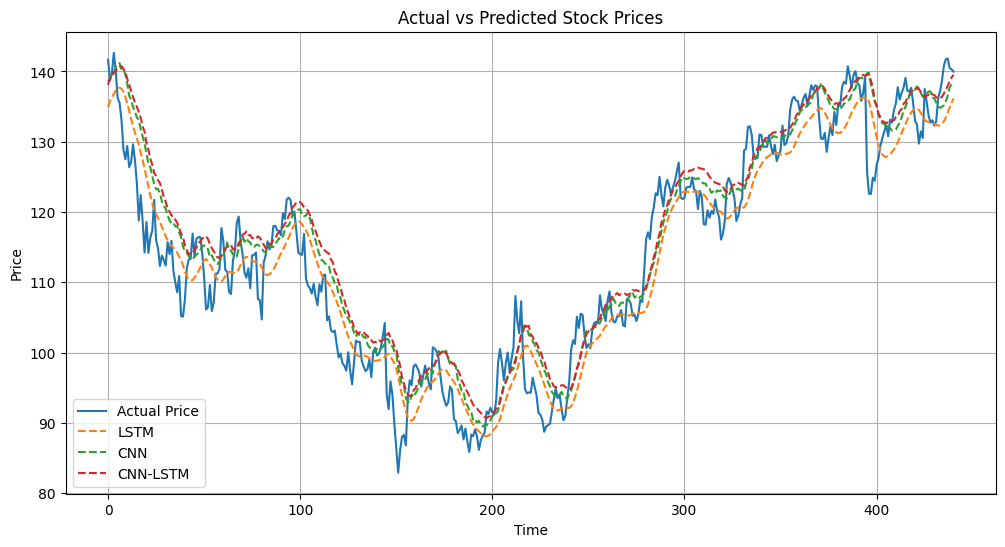


📊 MODEL PERFORMANCE COMPARISON TABLE:

      Model        MSE      RMSE  R² Score
0      LSTM  23.083036  4.804481  0.905147
1       CNN  26.976302  5.193872  0.889149
2  CNN-LSTM  32.127606  5.668122  0.867981


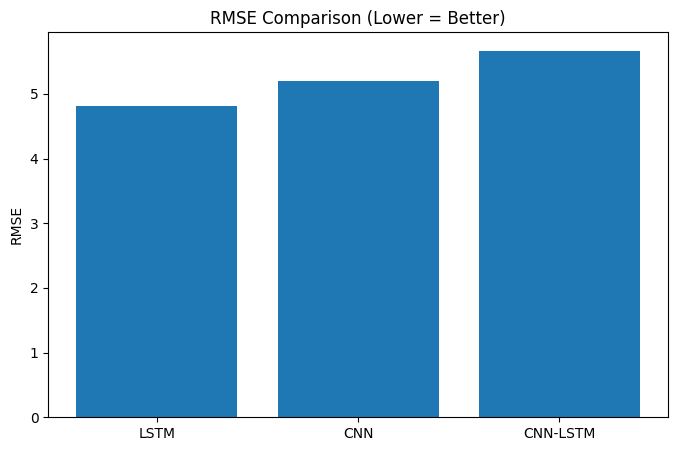

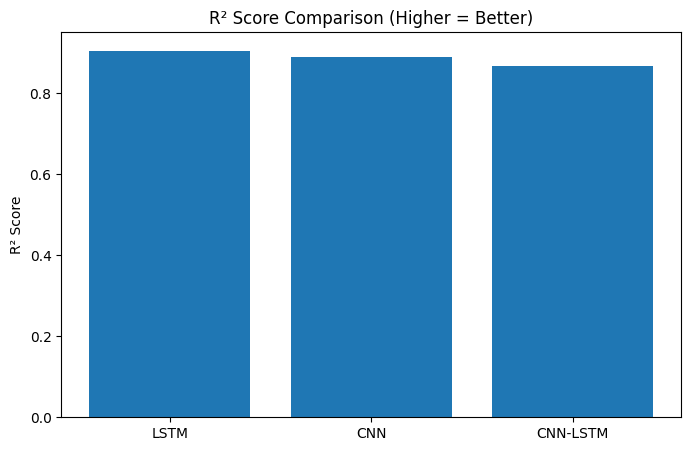

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Flatten, Dense

# ----------------- Load Data -----------------
stock = "GOOG"   # Change Stock Symbol
data = yf.download(stock, start="2015-01-01", end="2024-01-01")
data = data[['Close']]

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

X_train = X[:int(len(X)*0.8)]
y_train = y[:int(len(y)*0.8)]
X_test  = X[int(len(X)*0.8):]
y_test  = y[int(len(y)*0.8):]

# ----------------- Model 1: LSTM -----------------
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step,1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test)

# ----------------- Model 2: CNN -----------------
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step,1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test)

# ----------------- Model 3: CNN-LSTM -----------------
cnn_lstm_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step,1)),
    MaxPooling1D(pool_size=2),
    LSTM(50),
    Dense(1)
])
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test)

# ----------------- Inverse Transform -----------------
actual = scaler.inverse_transform(y_test)
lstm_pred = scaler.inverse_transform(lstm_pred)
cnn_pred = scaler.inverse_transform(cnn_pred)
cnn_lstm_pred = scaler.inverse_transform(cnn_lstm_pred)

# ----------------- Plot All Models in One Figure -----------------
plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual Price')
plt.plot(lstm_pred, label='LSTM', linestyle='dashed')
plt.plot(cnn_pred, label='CNN', linestyle='dashed')
plt.plot(cnn_lstm_pred, label='CNN-LSTM', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Model Performance Table -----------------
def evaluate(name, true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return [name, mse, rmse, r2]

results = [
    evaluate("LSTM", actual, lstm_pred),
    evaluate("CNN", actual, cnn_pred),
    evaluate("CNN-LSTM", actual, cnn_lstm_pred)
]

perf_table = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R² Score"])
print("\n📊 MODEL PERFORMANCE COMPARISON TABLE:\n")
print(perf_table)

# ----------------- Performance Bar Charts -----------------
plt.figure(figsize=(8,5))
plt.bar(perf_table["Model"], perf_table["RMSE"])
plt.title("RMSE Comparison (Lower = Better)")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(perf_table["Model"], perf_table["R² Score"])
plt.title("R² Score Comparison (Higher = Better)")
plt.ylabel("R² Score")
plt.show()

In [ ]:
lstm_model.save("stock_price_model.keras")

In [ ]:
cnn_model.save("price_model.keras")

In [ ]:
cnn_lstm_model.save("cnn_lstm_stock_price_model.keras")

GOOGLE DATASET USE

/tmp/ipython-input-263355052.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


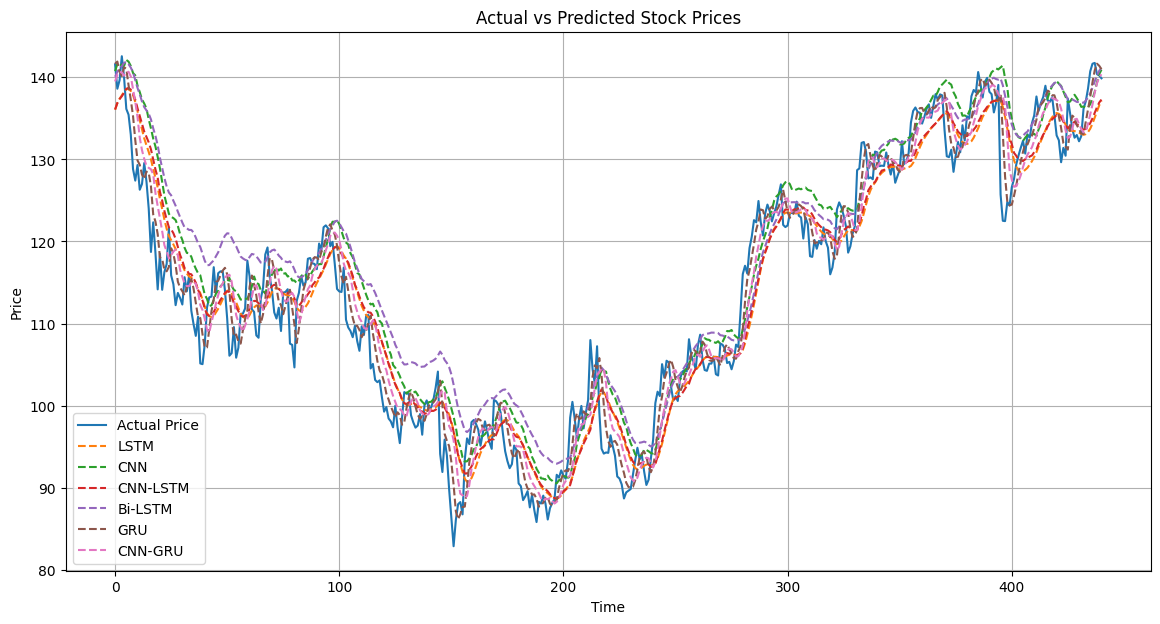


MODEL PERFORMANCE COMPARISON TABLE:

      Model        MSE      RMSE  R² Score
0      LSTM  21.720763  4.660554  0.910628
1       CNN  30.139928  5.489984  0.875987
2  CNN-LSTM  21.617095  4.649419  0.911055
3   Bi-LSTM  40.620634  6.373432  0.832863
4       GRU   8.621499  2.936239  0.964526
5   CNN-GRU  16.421885  4.052393  0.932431


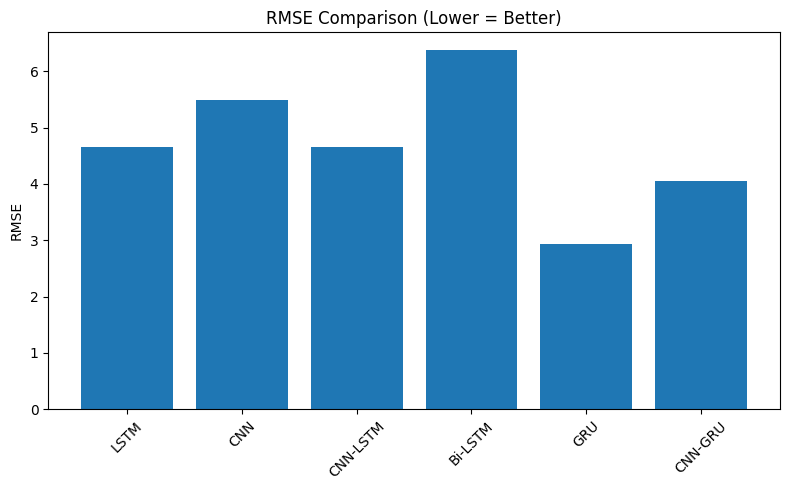

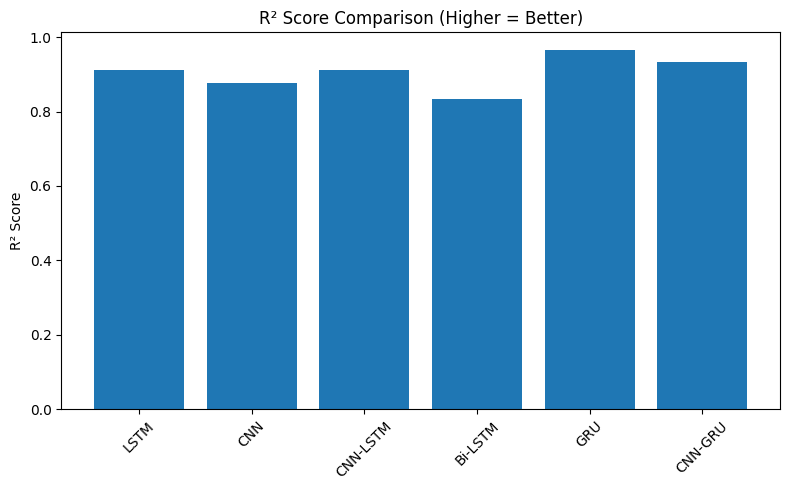

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Bidirectional,
)

# ----------------- Load Data -----------------
stock = "GOOG"   # Change Stock Symbol
data = yf.download(stock, start="2015-01-01", end="2024-01-01")
data = data[['Close']]

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Train / Test split
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test,  y_test  = X[train_size:], y[train_size:]

# ----------------- Model 1: LSTM -----------------
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test)

# ----------------- Model 2: CNN -----------------
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test)

# ----------------- Model 3: CNN-LSTM -----------------
cnn_lstm_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(50),
    Dense(1)
])
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test)

# ----------------- Model 4: Bi-LSTM -----------------
bilstm_model = Sequential([
    Bidirectional(LSTM(50), input_shape=(time_step, 1)),
    Dense(1)
])
bilstm_model.compile(optimizer='adam', loss='mse')
bilstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
bilstm_pred = bilstm_model.predict(X_test)

# ----------------- Model 5: GRU -----------------
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(time_step, 1)),
    GRU(50),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
gru_pred = gru_model.predict(X_test)

# ----------------- Model 6: CNN-GRU (Hybrid) -----------------
cnn_gru_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    GRU(50),
    Dense(1)
])
cnn_gru_model.compile(optimizer='adam', loss='mse')
cnn_gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_gru_pred = cnn_gru_model.predict(X_test)

# ----------------- Inverse Transform -----------------
actual = scaler.inverse_transform(y_test)

lstm_pred      = scaler.inverse_transform(lstm_pred)
cnn_pred       = scaler.inverse_transform(cnn_pred)
cnn_lstm_pred  = scaler.inverse_transform(cnn_lstm_pred)
bilstm_pred    = scaler.inverse_transform(bilstm_pred)
gru_pred       = scaler.inverse_transform(gru_pred)
cnn_gru_pred   = scaler.inverse_transform(cnn_gru_pred)

# ----------------- Plot All Models in One Figure -----------------
plt.figure(figsize=(14, 7))
plt.plot(actual, label='Actual Price')
plt.plot(lstm_pred, label='LSTM', linestyle='dashed')
plt.plot(cnn_pred, label='CNN', linestyle='dashed')
plt.plot(cnn_lstm_pred, label='CNN-LSTM', linestyle='dashed')
plt.plot(bilstm_pred, label='Bi-LSTM', linestyle='dashed')
plt.plot(gru_pred, label='GRU', linestyle='dashed')
plt.plot(cnn_gru_pred, label='CNN-GRU', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Model Performance Table -----------------
def evaluate(name, true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return [name, mse, rmse, r2]

results = [
    evaluate("LSTM",      actual, lstm_pred),
    evaluate("CNN",       actual, cnn_pred),
    evaluate("CNN-LSTM",  actual, cnn_lstm_pred),
    evaluate("Bi-LSTM",   actual, bilstm_pred),
    evaluate("GRU",       actual, gru_pred),
    evaluate("CNN-GRU",   actual, cnn_gru_pred),
]

perf_table = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R² Score"])
print("\nMODEL PERFORMANCE COMPARISON TABLE:\n")
print(perf_table)

# ----------------- Performance Bar Charts -----------------
plt.figure(figsize=(8, 5))
plt.bar(perf_table["Model"], perf_table["RMSE"])
plt.title("RMSE Comparison (Lower = Better)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(perf_table["Model"], perf_table["R² Score"])
plt.title("R² Score Comparison (Higher = Better)")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
gru_model.save("gru_model.keras")
cnn_gru_model.save("cnn_gru_model.keras")
bilstm_model.save("bilstm_model.keras")


/tmp/ipython-input-3799846198.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0104 - val_loss: 0.0012
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0011 - val_loss: 9.9724e-04
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 7.7385e-04 - val_loss: 7.9546e-04
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 6.7473e-04 - val_loss: 7.6179e-04
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 6.8751e-04 - val_loss: 7.3942e-04
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 6.8660e-04 - val_loss: 7.3205e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 6.2290e-04 - val_loss: 7.5244e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 6.2141e-04 - val_loss: 8.3597e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 5.3334e-04 - val_loss: 6.6716e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 5.3718e-04 - val_loss: 6.5116e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 6.0908e-04 - val_loss: 6.9833e-

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0100 - val_loss: 9.9261e-04
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0042
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0034
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 0.0018
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss: 0.0040
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.8071e-04 - val_loss: 0.0020
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0023
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0138 - val_loss: 0.0012
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 8.3172e-04 - val_loss: 0.0011
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 8.0303e-04 - val_loss: 0.0012
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 8.0313e-04 - val_loss: 9.2057e-04
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.9777e-04 - val_loss: 9.3568e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 6.2914e-04 - val_loss: 8.2492e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 6.5146e-04 - val_loss: 7.7236e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 6.3160e-04 - val_loss: 7.5226e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 5.6645e-04 - val_loss: 8.6510e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 5.3156e-04 - val_loss: 6.9990e-04
Epoch 12/2

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0094 - val_loss: 0.0033
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0013 - val_loss: 5.5872e-04
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 6.2134e-04 - val_loss: 5.8241e-04
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.4197e-04 - val_loss: 8.3656e-04
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.6684e-04 - val_loss: 6.2395e-04
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.5222e-04 - val_loss: 4.9583e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.5105e-04 - val_loss: 5.0947e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.5801e-04 - val_loss: 5.7568e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 4.1662e-04 - val_loss: 5.8709e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 4.5320e-04 - val_loss: 5.6134e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 4.4179e-04 - val_loss: 4.6527e-0

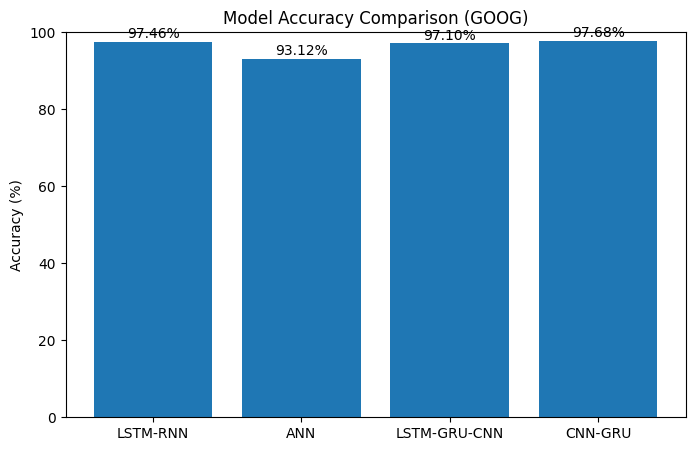

In [ ]:
# ======================================================
# 1. Install & Imports
# ======================================================
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU, Conv1D, MaxPooling1D
)

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ======================================================
# 2. Load, Clean & Prepare Stock Data
# ======================================================
ticker = "GOOG"       # change this if needed
years  = 5            # last N years

df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)

# Keep only 'Close' and drop missing values
data = df[['Close']].dropna()

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)   # shape (n, 1)

# ======================================================
# 3. Create Sequences
# ======================================================
def create_sequences(dataset, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(dataset)):
        X.append(dataset[i - seq_len:i, 0])   # last seq_len prices
        y.append(dataset[i, 0])               # next price
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(scaled_data, seq_len=seq_len)

# For RNN / CNN-based models (3D)
X_seq = X.reshape((X.shape[0], X.shape[1], 1))
# For ANN (2D)
X_flat = X.reshape((X.shape[0], X.shape[1]))

# ======================================================
# 4. Train / Test Split
# ======================================================
split_ratio = 0.8
split_index = int(len(X_seq) * split_ratio)

X_seq_train, X_seq_test = X_seq[:split_index], X_seq[split_index:]
X_flat_train, X_flat_test = X_flat[:split_index], X_flat[split_index:]

y_train, y_test = y[:split_index], y[split_index:]

# Inverse transform baseline for all models
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

# ======================================================
# 5. Accuracy Function (Regression)
# ======================================================
def regression_accuracy(y_true_inv, y_pred_inv):
    """
    Accuracy = 1 - (MAE / mean(|y_true|))  -> in %
    """
    mae = np.mean(np.abs(y_true_inv - y_pred_inv))
    mean_true = np.mean(np.abs(y_true_inv)) + 1e-8  # avoid /0
    acc = 1 - (mae / mean_true)
    return acc * 100.0

# ======================================================
# 6. Build Models
# ======================================================
def build_lstm_rnn(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_gru_cnn(input_shape):
    # CNN + LSTM + GRU hybrid
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_cnn_gru(input_shape):
    # CNN + GRU
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ======================================================
# 7. Train All Models & Compute ONLY Accuracy (%)
# ======================================================
EPOCHS = 20
BATCH_SIZE = 32

results = {}   # model_name -> accuracy

# ---------- LSTM-RNN ----------
model_lstm = build_lstm_rnn(input_shape=(seq_len, 1))
model_lstm.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_lstm_scaled = model_lstm.predict(X_seq_test)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm_scaled).ravel()
acc_lstm = regression_accuracy(y_test_inv, y_pred_lstm_inv)
results['LSTM-RNN'] = acc_lstm
print(f"LSTM-RNN Accuracy: {acc_lstm:.2f}%")

# ---------- ANN ----------
model_ann = build_ann(input_dim=seq_len)
model_ann.fit(
    X_flat_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_ann_scaled = model_ann.predict(X_flat_test)
y_pred_ann_inv = scaler.inverse_transform(y_pred_ann_scaled).ravel()
acc_ann = regression_accuracy(y_test_inv, y_pred_ann_inv)
results['ANN'] = acc_ann
print(f"ANN Accuracy: {acc_ann:.2f}%")

# ---------- LSTM-GRU-CNN Hybrid ----------
model_hybrid = build_lstm_gru_cnn(input_shape=(seq_len, 1))
model_hybrid.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_hybrid_scaled = model_hybrid.predict(X_seq_test)
y_pred_hybrid_inv = scaler.inverse_transform(y_pred_hybrid_scaled).ravel()
acc_hybrid = regression_accuracy(y_test_inv, y_pred_hybrid_inv)
results['LSTM-GRU-CNN'] = acc_hybrid
print(f"LSTM-GRU-CNN Accuracy: {acc_hybrid:.2f}%")

# ---------- CNN-GRU ----------
model_cnn_gru = build_cnn_gru(input_shape=(seq_len, 1))
model_cnn_gru.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_cnn_gru_scaled = model_cnn_gru.predict(X_seq_test)
y_pred_cnn_gru_inv = scaler.inverse_transform(y_pred_cnn_gru_scaled).ravel()
acc_cnn_gru = regression_accuracy(y_test_inv, y_pred_cnn_gru_inv)
results['CNN-GRU'] = acc_cnn_gru
print(f"CNN-GRU Accuracy: {acc_cnn_gru:.2f}%")

# ======================================================
# 8. Compare Graph (Accuracy Bar Chart)
# ======================================================
model_names = list(results.keys())
accuracies = [results[m] for m in model_names]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy (%)")
plt.title(f"Model Accuracy Comparison ({ticker})")
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()


state bank data setuse

/tmp/ipython-input-2456726351.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


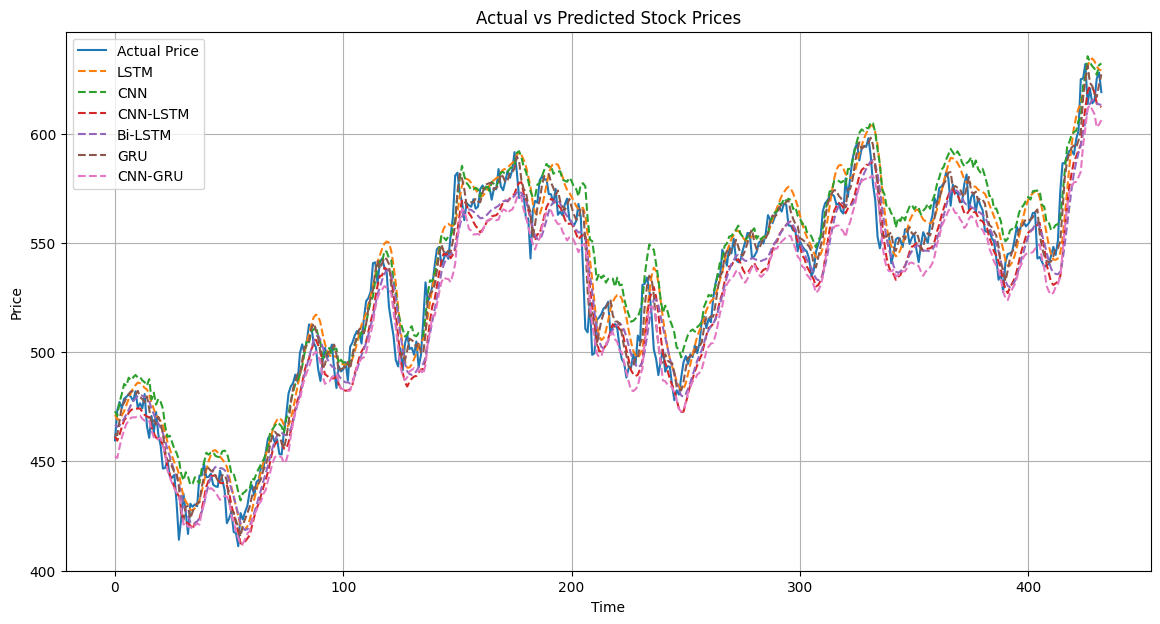


MODEL PERFORMANCE COMPARISON TABLE:

      Model         MSE       RMSE  R² Score
0      LSTM  176.780737  13.295892  0.923288
1       CNN  234.174288  15.302754  0.898383
2  CNN-LSTM  168.222689  12.970069  0.927002
3   Bi-LSTM  180.581502  13.438062  0.921639
4       GRU   67.324108   8.205127  0.970786
5   CNN-GRU  230.791108  15.191811  0.899851


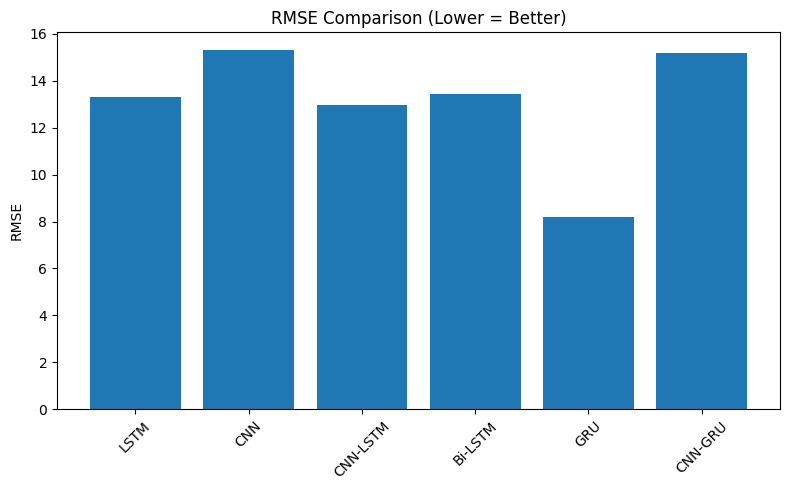

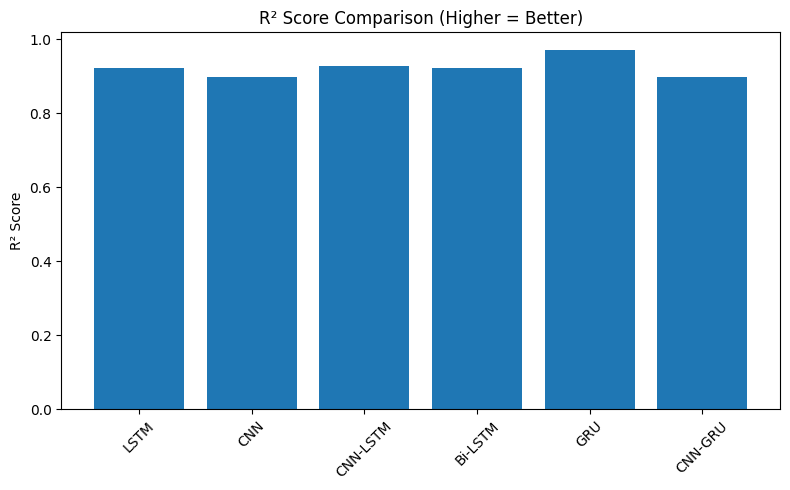

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Bidirectional,
)

# ----------------- Load Data -----------------
stock = "SBIN.NS"   # Change Stock Symbol
data = yf.download(stock, start="2015-01-01", end="2024-01-01")
data = data[['Close']]

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Train / Test split
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test,  y_test  = X[train_size:], y[train_size:]

# ----------------- Model 1: LSTM -----------------
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test)

# ----------------- Model 2: CNN -----------------
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test)

# ----------------- Model 3: CNN-LSTM -----------------
cnn_lstm_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(50),
    Dense(1)
])
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test)

# ----------------- Model 4: Bi-LSTM -----------------
bilstm_model = Sequential([
    Bidirectional(LSTM(50), input_shape=(time_step, 1)),
    Dense(1)
])
bilstm_model.compile(optimizer='adam', loss='mse')
bilstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
bilstm_pred = bilstm_model.predict(X_test)

# ----------------- Model 5: GRU -----------------
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(time_step, 1)),
    GRU(50),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
gru_pred = gru_model.predict(X_test)

# ----------------- Model 6: CNN-GRU (Hybrid) -----------------
cnn_gru_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    GRU(50),
    Dense(1)
])
cnn_gru_model.compile(optimizer='adam', loss='mse')
cnn_gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_gru_pred = cnn_gru_model.predict(X_test)

# ----------------- Inverse Transform -----------------
actual = scaler.inverse_transform(y_test)

lstm_pred      = scaler.inverse_transform(lstm_pred)
cnn_pred       = scaler.inverse_transform(cnn_pred)
cnn_lstm_pred  = scaler.inverse_transform(cnn_lstm_pred)
bilstm_pred    = scaler.inverse_transform(bilstm_pred)
gru_pred       = scaler.inverse_transform(gru_pred)
cnn_gru_pred   = scaler.inverse_transform(cnn_gru_pred)

# ----------------- Plot All Models in One Figure -----------------
plt.figure(figsize=(14, 7))
plt.plot(actual, label='Actual Price')
plt.plot(lstm_pred, label='LSTM', linestyle='dashed')
plt.plot(cnn_pred, label='CNN', linestyle='dashed')
plt.plot(cnn_lstm_pred, label='CNN-LSTM', linestyle='dashed')
plt.plot(bilstm_pred, label='Bi-LSTM', linestyle='dashed')
plt.plot(gru_pred, label='GRU', linestyle='dashed')
plt.plot(cnn_gru_pred, label='CNN-GRU', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Model Performance Table -----------------
def evaluate(name, true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return [name, mse, rmse, r2]

results = [
    evaluate("LSTM",      actual, lstm_pred),
    evaluate("CNN",       actual, cnn_pred),
    evaluate("CNN-LSTM",  actual, cnn_lstm_pred),
    evaluate("Bi-LSTM",   actual, bilstm_pred),
    evaluate("GRU",       actual, gru_pred),
    evaluate("CNN-GRU",   actual, cnn_gru_pred),
]

perf_table = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R² Score"])
print("\nMODEL PERFORMANCE COMPARISON TABLE:\n")
print(perf_table)

# ----------------- Performance Bar Charts -----------------
plt.figure(figsize=(8, 5))
plt.bar(perf_table["Model"], perf_table["RMSE"])
plt.title("RMSE Comparison (Lower = Better)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(perf_table["Model"], perf_table["R² Score"])
plt.title("R² Score Comparison (Higher = Better)")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3834541996.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0467 - val_loss: 9.3409e-04
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0040 - val_loss: 0.0014
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0020 - val_loss: 8.9400e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0017 - val_loss: 9.0987e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0018 - val_loss: 8.8230e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0021 - val_loss: 0.0026
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0024 - val_loss: 8.9333e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0019 - val_loss: 8.2858e-04
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0290 - val_loss: 0.0031
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0089 - val_loss: 0.0026
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0082 - val_loss: 0.0116
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - val_loss: 0.0204
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0064
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0051 - val_loss: 0.0077
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - val_loss: 0.0270
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - val_loss: 0.0085
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 0.0113
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - val_loss: 0.0087
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041 - val_loss: 0.0023
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038 - val_loss: 0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0562 - val_loss: 0.0018
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0056 - val_loss: 0.0024
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0021 - val_loss: 0.0010
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0020 - val_loss: 9.5509e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0021 - val_loss: 0.0010
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0020 - val_loss: 8.6824e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0017 - val_loss: 8.5790e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0767 - val_loss: 0.0365
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0067 - val_loss: 0.0054
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0031 - val_loss: 0.0020
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0027 - val_loss: 6.0403e-04
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0020 - val_loss: 5.5668e-04
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0017 - val_loss: 5.5841e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0017 - val_loss: 6.3017e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0019 - val_loss: 5.3626e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0015 - val_loss: 5.8628e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0014 - val_loss: 5.4455e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0015 - val_loss: 5.1486e-04
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 

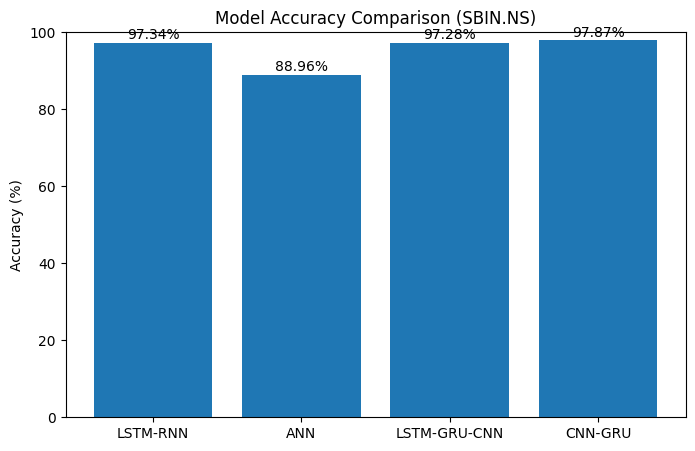

In [ ]:
# ======================================================
# 1. Install & Imports
# ======================================================
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU, Conv1D, MaxPooling1D
)

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ======================================================
# 2. Load, Clean & Prepare Stock Data
# ======================================================
ticker = "SBIN.NS"       # change this if needed
years  = 5            # last N years

df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)

# Keep only 'Close' and drop missing values
data = df[['Close']].dropna()

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)   # shape (n, 1)

# ======================================================
# 3. Create Sequences
# ======================================================
def create_sequences(dataset, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(dataset)):
        X.append(dataset[i - seq_len:i, 0])   # last seq_len prices
        y.append(dataset[i, 0])               # next price
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(scaled_data, seq_len=seq_len)

# For RNN / CNN-based models (3D)
X_seq = X.reshape((X.shape[0], X.shape[1], 1))
# For ANN (2D)
X_flat = X.reshape((X.shape[0], X.shape[1]))

# ======================================================
# 4. Train / Test Split
# ======================================================
split_ratio = 0.8
split_index = int(len(X_seq) * split_ratio)

X_seq_train, X_seq_test = X_seq[:split_index], X_seq[split_index:]
X_flat_train, X_flat_test = X_flat[:split_index], X_flat[split_index:]

y_train, y_test = y[:split_index], y[split_index:]

# Inverse transform baseline for all models
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

# ======================================================
# 5. Accuracy Function (Regression)
# ======================================================
def regression_accuracy(y_true_inv, y_pred_inv):
    """
    Accuracy = 1 - (MAE / mean(|y_true|))  -> in %
    """
    mae = np.mean(np.abs(y_true_inv - y_pred_inv))
    mean_true = np.mean(np.abs(y_true_inv)) + 1e-8  # avoid /0
    acc = 1 - (mae / mean_true)
    return acc * 100.0

# ======================================================
# 6. Build Models
# ======================================================
def build_lstm_rnn(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_gru_cnn(input_shape):
    # CNN + LSTM + GRU hybrid
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_cnn_gru(input_shape):
    # CNN + GRU
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ======================================================
# 7. Train All Models & Compute ONLY Accuracy (%)
# ======================================================
EPOCHS = 20
BATCH_SIZE = 32

results = {}   # model_name -> accuracy

# ---------- LSTM-RNN ----------
model_lstm = build_lstm_rnn(input_shape=(seq_len, 1))
model_lstm.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_lstm_scaled = model_lstm.predict(X_seq_test)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm_scaled).ravel()
acc_lstm = regression_accuracy(y_test_inv, y_pred_lstm_inv)
results['LSTM-RNN'] = acc_lstm
print(f"LSTM-RNN Accuracy: {acc_lstm:.2f}%")

# ---------- ANN ----------
model_ann = build_ann(input_dim=seq_len)
model_ann.fit(
    X_flat_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_ann_scaled = model_ann.predict(X_flat_test)
y_pred_ann_inv = scaler.inverse_transform(y_pred_ann_scaled).ravel()
acc_ann = regression_accuracy(y_test_inv, y_pred_ann_inv)
results['ANN'] = acc_ann
print(f"ANN Accuracy: {acc_ann:.2f}%")

# ---------- LSTM-GRU-CNN Hybrid ----------
model_hybrid = build_lstm_gru_cnn(input_shape=(seq_len, 1))
model_hybrid.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_hybrid_scaled = model_hybrid.predict(X_seq_test)
y_pred_hybrid_inv = scaler.inverse_transform(y_pred_hybrid_scaled).ravel()
acc_hybrid = regression_accuracy(y_test_inv, y_pred_hybrid_inv)
results['LSTM-GRU-CNN'] = acc_hybrid
print(f"LSTM-GRU-CNN Accuracy: {acc_hybrid:.2f}%")

# ---------- CNN-GRU ----------
model_cnn_gru = build_cnn_gru(input_shape=(seq_len, 1))
model_cnn_gru.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_cnn_gru_scaled = model_cnn_gru.predict(X_seq_test)
y_pred_cnn_gru_inv = scaler.inverse_transform(y_pred_cnn_gru_scaled).ravel()
acc_cnn_gru = regression_accuracy(y_test_inv, y_pred_cnn_gru_inv)
results['CNN-GRU'] = acc_cnn_gru
print(f"CNN-GRU Accuracy: {acc_cnn_gru:.2f}%")

# ======================================================
# 8. Compare Graph (Accuracy Bar Chart)
# ======================================================
model_names = list(results.keys())
accuracies = [results[m] for m in model_names]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy (%)")
plt.title(f"Model Accuracy Comparison ({ticker})")
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()


MRF DATASET USE

/tmp/ipython-input-3872373725.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


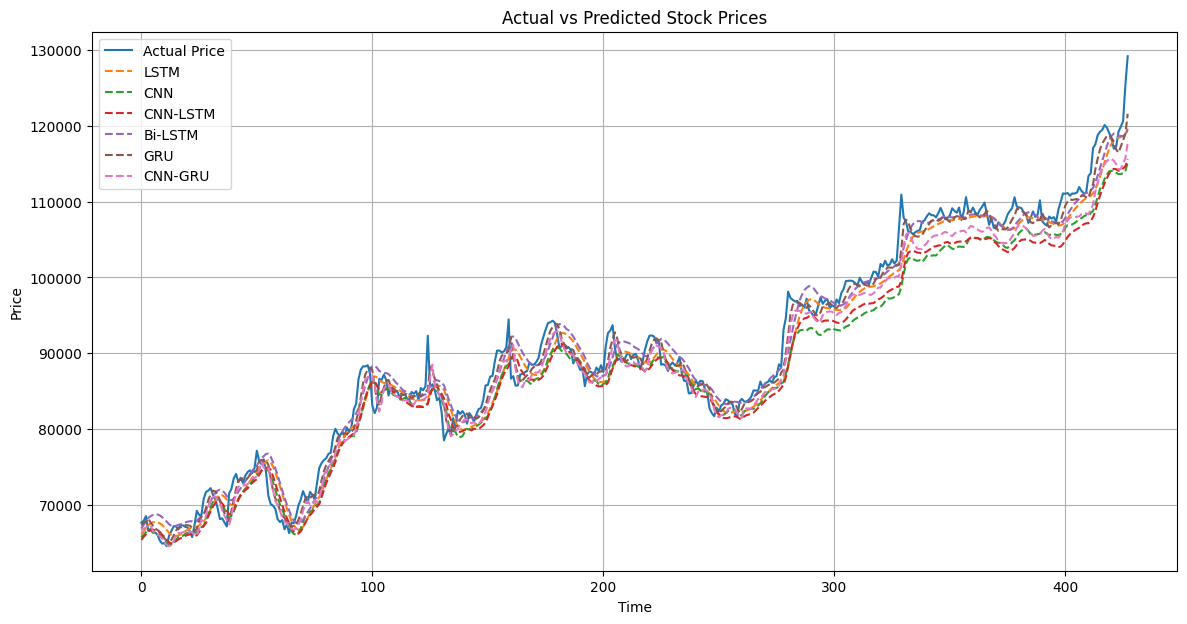


MODEL PERFORMANCE COMPARISON TABLE:

      Model           MSE         RMSE  R² Score
0      LSTM  6.857869e+06  2618.753288  0.966026
1       CNN  1.197769e+07  3460.880334  0.940663
2  CNN-LSTM  1.231475e+07  3509.237742  0.938993
3   Bi-LSTM  5.634220e+06  2373.651142  0.972088
4       GRU  2.765565e+06  1662.998696  0.986300
5   CNN-GRU  6.270465e+06  2504.089719  0.968936


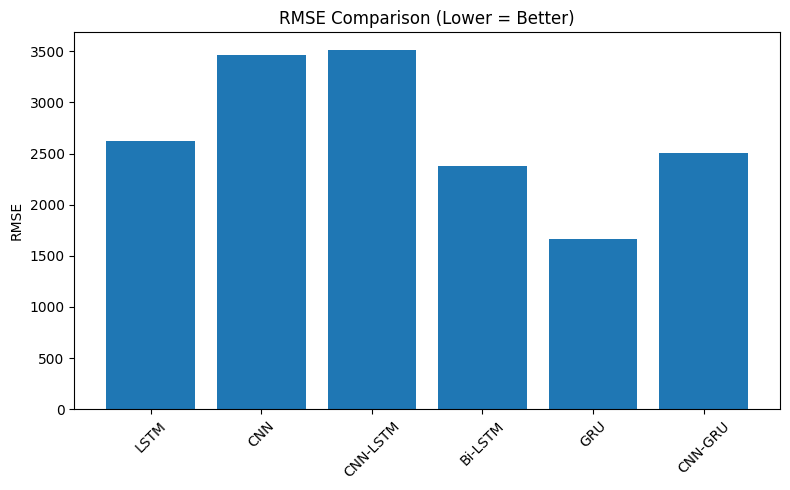

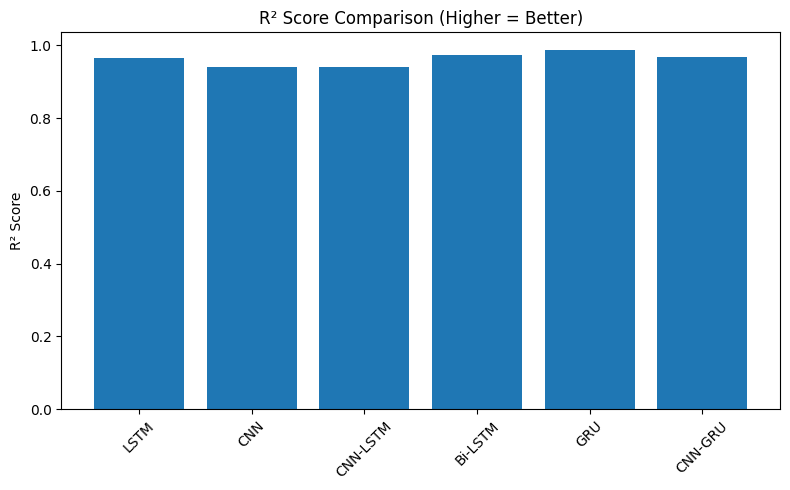

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Bidirectional,
)

# ----------------- Load Data -----------------
stock = "MRF.BO"   # Change Stock Symbol
data = yf.download(stock, start="2015-01-01", end="2024-01-01")
data = data[['Close']]

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Train / Test split
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test,  y_test  = X[train_size:], y[train_size:]

# ----------------- Model 1: LSTM -----------------
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test)

# ----------------- Model 2: CNN -----------------
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test)

# ----------------- Model 3: CNN-LSTM -----------------
cnn_lstm_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(50),
    Dense(1)
])
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test)

# ----------------- Model 4: Bi-LSTM -----------------
bilstm_model = Sequential([
    Bidirectional(LSTM(50), input_shape=(time_step, 1)),
    Dense(1)
])
bilstm_model.compile(optimizer='adam', loss='mse')
bilstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
bilstm_pred = bilstm_model.predict(X_test)

# ----------------- Model 5: GRU -----------------
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(time_step, 1)),
    GRU(50),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
gru_pred = gru_model.predict(X_test)

# ----------------- Model 6: CNN-GRU (Hybrid) -----------------
cnn_gru_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    GRU(50),
    Dense(1)
])
cnn_gru_model.compile(optimizer='adam', loss='mse')
cnn_gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_gru_pred = cnn_gru_model.predict(X_test)

# ----------------- Inverse Transform -----------------
actual = scaler.inverse_transform(y_test)

lstm_pred      = scaler.inverse_transform(lstm_pred)
cnn_pred       = scaler.inverse_transform(cnn_pred)
cnn_lstm_pred  = scaler.inverse_transform(cnn_lstm_pred)
bilstm_pred    = scaler.inverse_transform(bilstm_pred)
gru_pred       = scaler.inverse_transform(gru_pred)
cnn_gru_pred   = scaler.inverse_transform(cnn_gru_pred)

# ----------------- Plot All Models in One Figure -----------------
plt.figure(figsize=(14, 7))
plt.plot(actual, label='Actual Price')
plt.plot(lstm_pred, label='LSTM', linestyle='dashed')
plt.plot(cnn_pred, label='CNN', linestyle='dashed')
plt.plot(cnn_lstm_pred, label='CNN-LSTM', linestyle='dashed')
plt.plot(bilstm_pred, label='Bi-LSTM', linestyle='dashed')
plt.plot(gru_pred, label='GRU', linestyle='dashed')
plt.plot(cnn_gru_pred, label='CNN-GRU', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Model Performance Table -----------------
def evaluate(name, true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return [name, mse, rmse, r2]

results = [
    evaluate("LSTM",      actual, lstm_pred),
    evaluate("CNN",       actual, cnn_pred),
    evaluate("CNN-LSTM",  actual, cnn_lstm_pred),
    evaluate("Bi-LSTM",   actual, bilstm_pred),
    evaluate("GRU",       actual, gru_pred),
    evaluate("CNN-GRU",   actual, cnn_gru_pred),
]

perf_table = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R² Score"])
print("\nMODEL PERFORMANCE COMPARISON TABLE:\n")
print(perf_table)

# ----------------- Performance Bar Charts -----------------
plt.figure(figsize=(8, 5))
plt.bar(perf_table["Model"], perf_table["RMSE"])
plt.title("RMSE Comparison (Lower = Better)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(perf_table["Model"], perf_table["R² Score"])
plt.title("R² Score Comparison (Higher = Better)")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2660686488.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - loss: 0.0538 - val_loss: 0.0028
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0034 - val_loss: 0.0069
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0022 - val_loss: 0.0042
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - val_loss: 0.0026
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 0.0018 - val_loss: 0.0025
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - loss: 0.0020 - val_loss: 0.0045
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0019 - val_loss: 0.0030
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0480 - val_loss: 0.0155
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0133 - val_loss: 0.0030
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - val_loss: 0.0045
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0070 - val_loss: 0.0056
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0070 - val_loss: 0.0094
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0064 - val_loss: 0.0027
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066 - val_loss: 0.0083
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0058 - val_loss: 0.0096
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - val_loss: 0.0022
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 - val_loss: 0.0026
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0049 - val_loss: 0.0112
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - val_loss: 0.0056

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0618 - val_loss: 0.0027
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0035 - val_loss: 0.0060
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0029 - val_loss: 0.0038
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0025 - val_loss: 0.0042
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0018 - val_loss: 0.0032
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0016 - val_l

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0389 - val_loss: 0.0091
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0017 - val_loss: 9.1752e-04
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0015 - val_loss: 8.6007e-04
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013

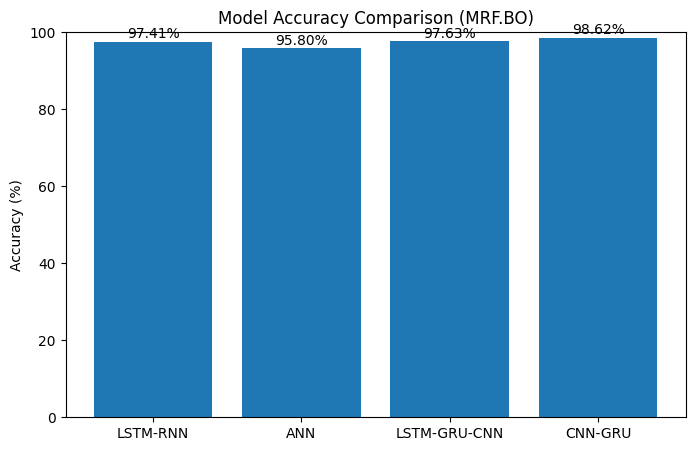

In [ ]:
# ======================================================
# 1. Install & Imports
# ======================================================
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU, Conv1D, MaxPooling1D
)

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ======================================================
# 2. Load, Clean & Prepare Stock Data
# ======================================================
ticker = "MRF.BO"       # change this if needed
years  = 5            # last N years

df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)

# Keep only 'Close' and drop missing values
data = df[['Close']].dropna()

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)   # shape (n, 1)

# ======================================================
# 3. Create Sequences
# ======================================================
def create_sequences(dataset, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(dataset)):
        X.append(dataset[i - seq_len:i, 0])   # last seq_len prices
        y.append(dataset[i, 0])               # next price
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(scaled_data, seq_len=seq_len)

# For RNN / CNN-based models (3D)
X_seq = X.reshape((X.shape[0], X.shape[1], 1))
# For ANN (2D)
X_flat = X.reshape((X.shape[0], X.shape[1]))

# ======================================================
# 4. Train / Test Split
# ======================================================
split_ratio = 0.8
split_index = int(len(X_seq) * split_ratio)

X_seq_train, X_seq_test = X_seq[:split_index], X_seq[split_index:]
X_flat_train, X_flat_test = X_flat[:split_index], X_flat[split_index:]

y_train, y_test = y[:split_index], y[split_index:]

# Inverse transform baseline for all models
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

# ======================================================
# 5. Accuracy Function (Regression)
# ======================================================
def regression_accuracy(y_true_inv, y_pred_inv):
    """
    Accuracy = 1 - (MAE / mean(|y_true|))  -> in %
    """
    mae = np.mean(np.abs(y_true_inv - y_pred_inv))
    mean_true = np.mean(np.abs(y_true_inv)) + 1e-8  # avoid /0
    acc = 1 - (mae / mean_true)
    return acc * 100.0

# ======================================================
# 6. Build Models
# ======================================================
def build_lstm_rnn(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_gru_cnn(input_shape):
    # CNN + LSTM + GRU hybrid
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_cnn_gru(input_shape):
    # CNN + GRU
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ======================================================
# 7. Train All Models & Compute ONLY Accuracy (%)
# ======================================================
EPOCHS = 20
BATCH_SIZE = 32

results = {}   # model_name -> accuracy

# ---------- LSTM-RNN ----------
model_lstm = build_lstm_rnn(input_shape=(seq_len, 1))
model_lstm.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_lstm_scaled = model_lstm.predict(X_seq_test)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm_scaled).ravel()
acc_lstm = regression_accuracy(y_test_inv, y_pred_lstm_inv)
results['LSTM-RNN'] = acc_lstm
print(f"LSTM-RNN Accuracy: {acc_lstm:.2f}%")

# ---------- ANN ----------
model_ann = build_ann(input_dim=seq_len)
model_ann.fit(
    X_flat_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_ann_scaled = model_ann.predict(X_flat_test)
y_pred_ann_inv = scaler.inverse_transform(y_pred_ann_scaled).ravel()
acc_ann = regression_accuracy(y_test_inv, y_pred_ann_inv)
results['ANN'] = acc_ann
print(f"ANN Accuracy: {acc_ann:.2f}%")

# ---------- LSTM-GRU-CNN Hybrid ----------
model_hybrid = build_lstm_gru_cnn(input_shape=(seq_len, 1))
model_hybrid.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_hybrid_scaled = model_hybrid.predict(X_seq_test)
y_pred_hybrid_inv = scaler.inverse_transform(y_pred_hybrid_scaled).ravel()
acc_hybrid = regression_accuracy(y_test_inv, y_pred_hybrid_inv)
results['LSTM-GRU-CNN'] = acc_hybrid
print(f"LSTM-GRU-CNN Accuracy: {acc_hybrid:.2f}%")

# ---------- CNN-GRU ----------
model_cnn_gru = build_cnn_gru(input_shape=(seq_len, 1))
model_cnn_gru.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_cnn_gru_scaled = model_cnn_gru.predict(X_seq_test)
y_pred_cnn_gru_inv = scaler.inverse_transform(y_pred_cnn_gru_scaled).ravel()
acc_cnn_gru = regression_accuracy(y_test_inv, y_pred_cnn_gru_inv)
results['CNN-GRU'] = acc_cnn_gru
print(f"CNN-GRU Accuracy: {acc_cnn_gru:.2f}%")

# ======================================================
# 8. Compare Graph (Accuracy Bar Chart)
# ======================================================
model_names = list(results.keys())
accuracies = [results[m] for m in model_names]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy (%)")
plt.title(f"Model Accuracy Comparison ({ticker})")
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()


ADANIPOWER DATASET USE

/tmp/ipython-input-848472279.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


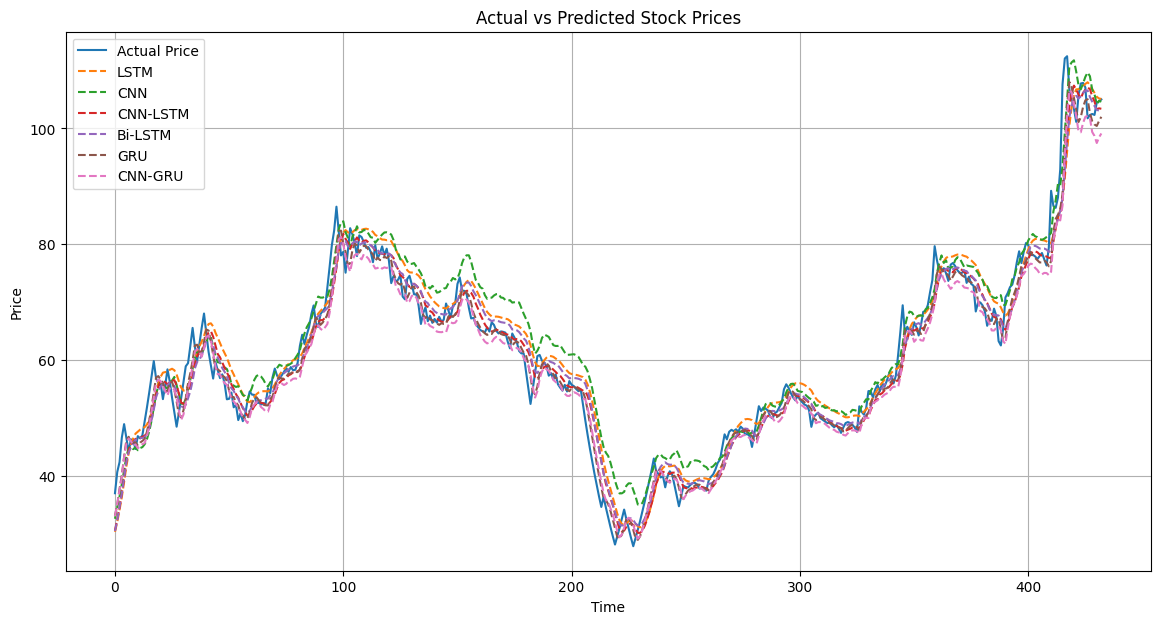


MODEL PERFORMANCE COMPARISON TABLE:

      Model        MSE      RMSE  R² Score
0      LSTM  17.313358  4.160932  0.934421
1       CNN  21.891752  4.678862  0.917079
2  CNN-LSTM  13.008599  3.606744  0.950726
3   Bi-LSTM  12.672656  3.559867  0.951999
4       GRU   7.911564  2.812750  0.970033
5   CNN-GRU  11.820586  3.438108  0.955226


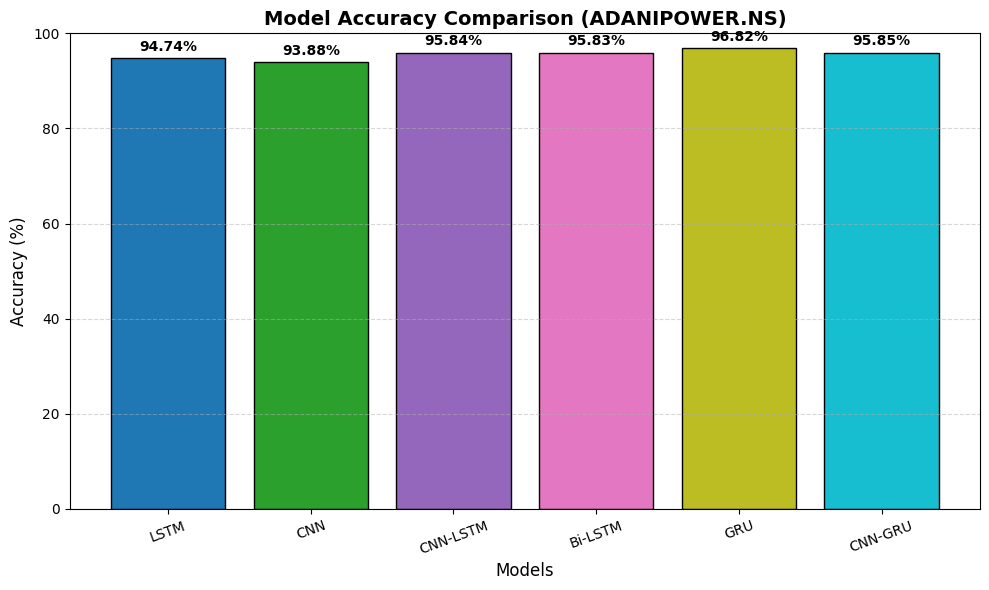

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Bidirectional,
)

# ----------------- Load Data -----------------
stock = "ADANIPOWER.NS"   # Change Stock Symbol
data = yf.download(stock, start="2015-01-01", end="2024-01-01")
data = data[['Close']]

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Train / Test split
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test,  y_test  = X[train_size:], y[train_size:]

# ----------------- Model 1: LSTM -----------------
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test)

# ----------------- Model 2: CNN -----------------
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test)

# ----------------- Model 3: CNN-LSTM -----------------
cnn_lstm_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(50),
    Dense(1)
])
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test)

# ----------------- Model 4: Bi-LSTM -----------------
bilstm_model = Sequential([
    Bidirectional(LSTM(50), input_shape=(time_step, 1)),
    Dense(1)
])
bilstm_model.compile(optimizer='adam', loss='mse')
bilstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
bilstm_pred = bilstm_model.predict(X_test)

# ----------------- Model 5: GRU -----------------
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(time_step, 1)),
    GRU(50),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
gru_pred = gru_model.predict(X_test)

# ----------------- Model 6: CNN-GRU (Hybrid) -----------------
cnn_gru_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, 1)),
    MaxPooling1D(pool_size=2),
    GRU(50),
    Dense(1)
])
cnn_gru_model.compile(optimizer='adam', loss='mse')
cnn_gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_gru_pred = cnn_gru_model.predict(X_test)

# ----------------- Inverse Transform -----------------
actual = scaler.inverse_transform(y_test)

lstm_pred      = scaler.inverse_transform(lstm_pred)
cnn_pred       = scaler.inverse_transform(cnn_pred)
cnn_lstm_pred  = scaler.inverse_transform(cnn_lstm_pred)
bilstm_pred    = scaler.inverse_transform(bilstm_pred)
gru_pred       = scaler.inverse_transform(gru_pred)
cnn_gru_pred   = scaler.inverse_transform(cnn_gru_pred)

# ----------------- Plot All Models in One Figure -----------------
plt.figure(figsize=(14, 7))
plt.plot(actual, label='Actual Price')
plt.plot(lstm_pred, label='LSTM', linestyle='dashed')
plt.plot(cnn_pred, label='CNN', linestyle='dashed')
plt.plot(cnn_lstm_pred, label='CNN-LSTM', linestyle='dashed')
plt.plot(bilstm_pred, label='Bi-LSTM', linestyle='dashed')
plt.plot(gru_pred, label='GRU', linestyle='dashed')
plt.plot(cnn_gru_pred, label='CNN-GRU', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Model Performance Table -----------------
def evaluate(name, true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return [name, mse, rmse, r2]

results = [
    evaluate("LSTM",      actual, lstm_pred),
    evaluate("CNN",       actual, cnn_pred),
    evaluate("CNN-LSTM",  actual, cnn_lstm_pred),
    evaluate("Bi-LSTM",   actual, bilstm_pred),
    evaluate("GRU",       actual, gru_pred),
    evaluate("CNN-GRU",   actual, cnn_gru_pred),
]

perf_table = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R² Score"])
print("\nMODEL PERFORMANCE COMPARISON TABLE:\n")
print(perf_table)

# ----------------- Accuracy Function (Regression) -----------------
def regression_accuracy(y_true_inv, y_pred_inv):
    """
    Accuracy = 1 - (MAE / mean(|y_true|))  -> in %
    """
    mae = np.mean(np.abs(y_true_inv - y_pred_inv))
    mean_true = np.mean(np.abs(y_true_inv)) + 1e-8  # avoid /0
    acc = 1 - (mae / mean_true)
    return acc * 100.0

# Inverse transform baseline for all accuracy calculations
y_test_inv = scaler.inverse_transform(y_test).ravel() # Ensure y_test is 1D for ravel

# Store accuracy in a new dictionary
accuracy_metrics = {
    "LSTM":      regression_accuracy(y_test_inv, lstm_pred.ravel()),
    "CNN":       regression_accuracy(y_test_inv, cnn_pred.ravel()),
    "CNN-LSTM":  regression_accuracy(y_test_inv, cnn_lstm_pred.ravel()),
    "Bi-LSTM":   regression_accuracy(y_test_inv, bilstm_pred.ravel()),
    "GRU":       regression_accuracy(y_test_inv, gru_pred.ravel()),
    "CNN-GRU":   regression_accuracy(y_test_inv, cnn_gru_pred.ravel()),
}

# ======================================================
# 8. Colorful Accuracy Comparison Bar Chart
# ======================================================
import matplotlib.pyplot as plt
import numpy as np

model_names = list(accuracy_metrics.keys())
accuracies  = [accuracy_metrics[m] for m in model_names]

# Color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')

plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.title(f"Model Accuracy Comparison ({stock})", fontsize=14, fontweight='bold') # Changed ticker to stock for consistency
plt.ylim(0, 100)

# Value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

/tmp/ipython-input-934143258.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0473 - val_loss: 0.0050
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0037 - val_loss: 0.0029
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0019 - val_l

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0471 - val_loss: 0.0085
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0032 - val_loss: 0.0016
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0023 - val_loss: 0.0027
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0013 - val_l

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
LSTM-GRU-CNN Accuracy: 97.50%
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0369 - val_loss: 0.0060
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - val_loss: 9.6248e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 9.7508e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 8.8460e-04
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
CNN-GRU Accuracy: 95.84%


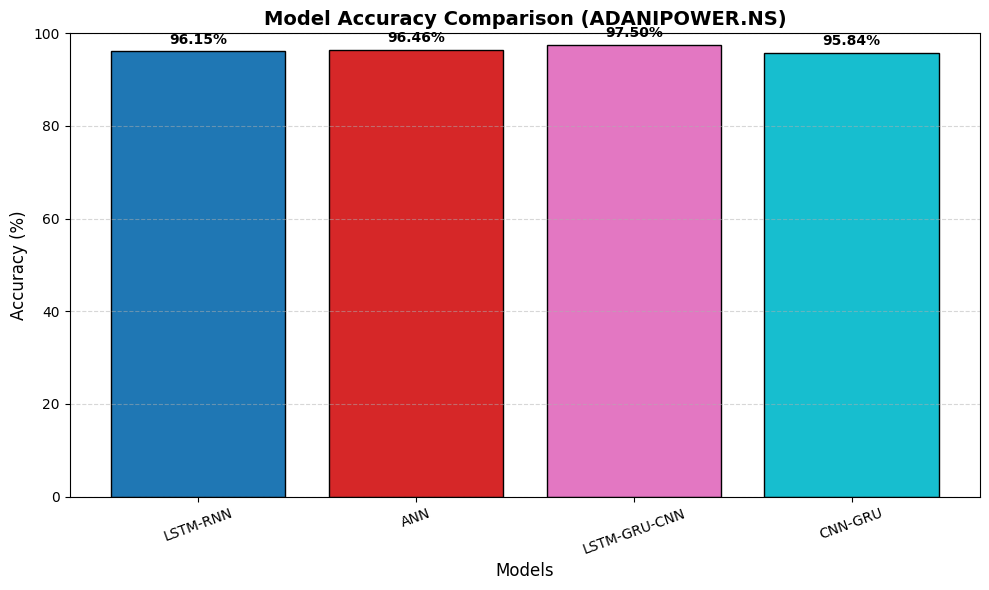

In [ ]:
# ======================================================
# 1. Install & Imports
# ======================================================
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU, Conv1D, MaxPooling1D
)

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ======================================================
# 2. Load, Clean & Prepare Stock Data
# ======================================================
ticker = "ADANIPOWER.NS"       # change this if needed
years  = 5            # last N years

df = yf.download(ticker, period=f"{years}y", interval="1d", progress=False)

# Keep only 'Close' and drop missing values
data = df[['Close']].dropna()

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)   # shape (n, 1)

# ======================================================
# 3. Create Sequences
# ======================================================
def create_sequences(dataset, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(dataset)):
        X.append(dataset[i - seq_len:i, 0])   # last seq_len prices
        y.append(dataset[i, 0])               # next price
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(scaled_data, seq_len=seq_len)

# For RNN / CNN-based models (3D)
X_seq = X.reshape((X.shape[0], X.shape[1], 1))
# For ANN (2D)
X_flat = X.reshape((X.shape[0], X.shape[1]))

# ======================================================
# 4. Train / Test Split
# ======================================================
split_ratio = 0.8
split_index = int(len(X_seq) * split_ratio)

X_seq_train, X_seq_test = X_seq[:split_index], X_seq[split_index:]
X_flat_train, X_flat_test = X_flat[:split_index], X_flat[split_index:]

y_train, y_test = y[:split_index], y[split_index:]

# Inverse transform baseline for all models
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

# ======================================================
# 5. Accuracy Function (Regression)
# ======================================================
def regression_accuracy(y_true_inv, y_pred_inv):
    """
    Accuracy = 1 - (MAE / mean(|y_true|))  -> in %
    """
    mae = np.mean(np.abs(y_true_inv - y_pred_inv))
    mean_true = np.mean(np.abs(y_true_inv)) + 1e-8  # avoid /0
    acc = 1 - (mae / mean_true)
    return acc * 100.0

# ======================================================
# 6. Build Models
# ======================================================
def build_lstm_rnn(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_gru_cnn(input_shape):
    # CNN + LSTM + GRU hybrid
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_cnn_gru(input_shape):
    # CNN + GRU
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(GRU(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ======================================================
# 7. Train All Models & Compute ONLY Accuracy (%)
# ======================================================
EPOCHS = 20
BATCH_SIZE = 32

results = {}   # model_name -> accuracy

# ---------- LSTM-RNN ----------
model_lstm = build_lstm_rnn(input_shape=(seq_len, 1))
model_lstm.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_lstm_scaled = model_lstm.predict(X_seq_test)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm_scaled).ravel()
acc_lstm = regression_accuracy(y_test_inv, y_pred_lstm_inv)
results['LSTM-RNN'] = acc_lstm
print(f"LSTM-RNN Accuracy: {acc_lstm:.2f}%")

# ---------- ANN ----------
model_ann = build_ann(input_dim=seq_len)
model_ann.fit(
    X_flat_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_ann_scaled = model_ann.predict(X_flat_test)
y_pred_ann_inv = scaler.inverse_transform(y_pred_ann_scaled).ravel()
acc_ann = regression_accuracy(y_test_inv, y_pred_ann_inv)
results['ANN'] = acc_ann
print(f"ANN Accuracy: {acc_ann:.2f}%")

# ---------- LSTM-GRU-CNN Hybrid ----------
model_hybrid = build_lstm_gru_cnn(input_shape=(seq_len, 1))
model_hybrid.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_hybrid_scaled = model_hybrid.predict(X_seq_test)
y_pred_hybrid_inv = scaler.inverse_transform(y_pred_hybrid_scaled).ravel()
acc_hybrid = regression_accuracy(y_test_inv, y_pred_hybrid_inv)
results['LSTM-GRU-CNN'] = acc_hybrid
print(f"LSTM-GRU-CNN Accuracy: {acc_hybrid:.2f}%")

# ---------- CNN-GRU ----------
model_cnn_gru = build_cnn_gru(input_shape=(seq_len, 1))
model_cnn_gru.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
y_pred_cnn_gru_scaled = model_cnn_gru.predict(X_seq_test)
y_pred_cnn_gru_inv = scaler.inverse_transform(y_pred_cnn_gru_scaled).ravel()
acc_cnn_gru = regression_accuracy(y_test_inv, y_pred_cnn_gru_inv)
results['CNN-GRU'] = acc_cnn_gru
print(f"CNN-GRU Accuracy: {acc_cnn_gru:.2f}%")

# ======================================================
# 8. Colorful Accuracy Comparison Bar Chart
# ======================================================
import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
accuracies  = [results[m] for m in model_names]

# Color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')

plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.title(f"Model Accuracy Comparison ({ticker})", fontsize=14, fontweight='bold')
plt.ylim(0, 100)

# Value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



In [ ]:
import yfinance as yf

data = yf.download(
    "GOOG",          # Stock ticker
    start="2019-01-01",
    end="2024-01-01",
    interval="1d"    # 1d, 1wk, 1mo
)

print(data.head())


/tmp/ipython-input-2176455610.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker           GOOG       GOOG       GOOG       GOOG      GOOG
Date                                                            
2019-01-02  51.903221  52.224314  50.407440  50.450119  30652000
2019-01-03  50.424805  52.455571  50.326043  51.662519  36822000
2019-01-04  53.136963  53.143415  50.988477  51.245154  41878000
2019-01-07  53.021824  53.300238  52.345398  53.176169  39638000
2019-01-08  53.413391  53.824311  52.631755  53.404955  35298000


In [ ]:
tickers = ["SBIN.NS", "GOOG", "ADANIPOWER.NS", "MRF.BO"]
data = yf.download(tickers, period="5y")


/tmp/ipython-input-2825778743.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="5y")
[*********************100%***********************]  4 of 4 completed


In [ ]:
data.to_csv("stock_data.csv")


/tmp/ipython-input-1640842109.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_s

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


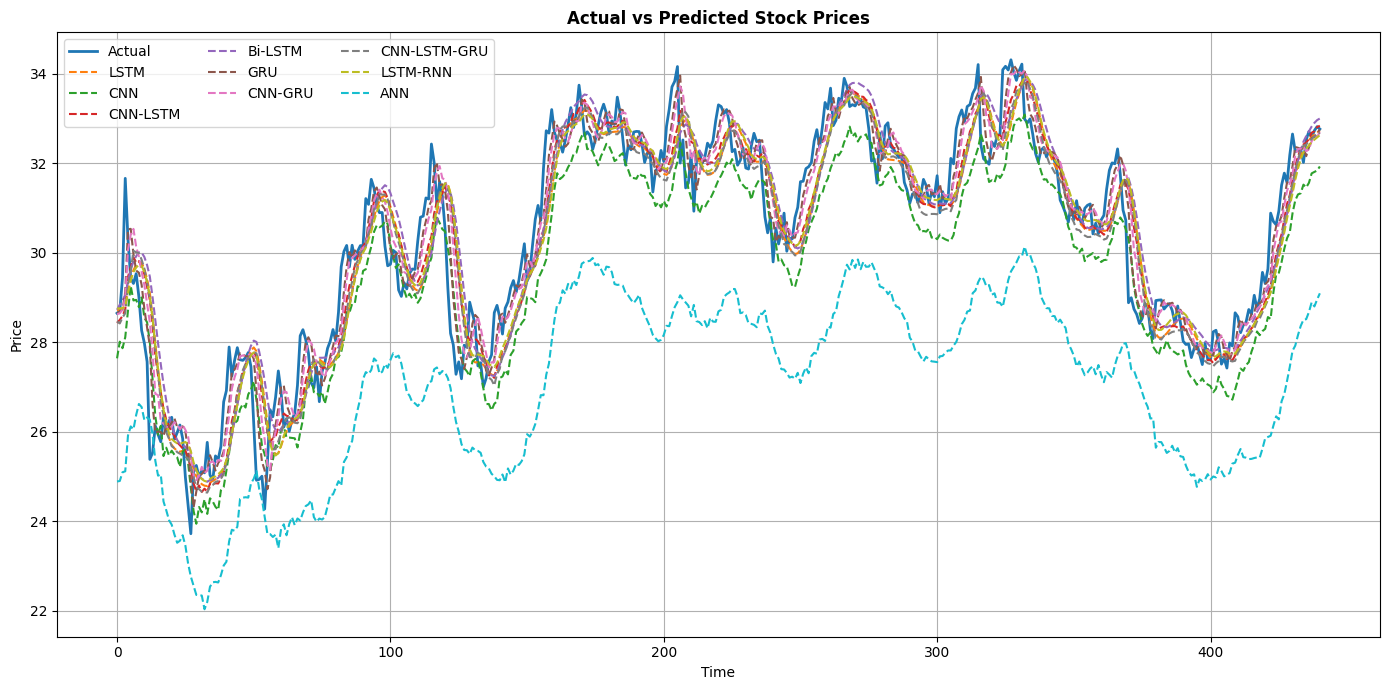


MODEL PERFORMANCE COMPARISON

          Model        MSE      RMSE  R² Score  Accuracy (%)
4           GRU   0.326489  0.571392  0.944897     98.609101
5       CNN-GRU   0.519684  0.720891  0.912291     98.259517
2      CNN-LSTM   0.735989  0.857898  0.875785     97.877897
7      LSTM-RNN   0.891267  0.944069  0.849578     97.653430
6  CNN-LSTM-GRU   0.873481  0.934602  0.852580     97.653286
0          LSTM   0.922748  0.960598  0.844265     97.610237
3       Bi-LSTM   1.008597  1.004289  0.829776     97.526166
1           CNN   1.209560  1.099800  0.795858     96.896145
8           ANN  12.099509  3.478435 -1.042077     88.994842


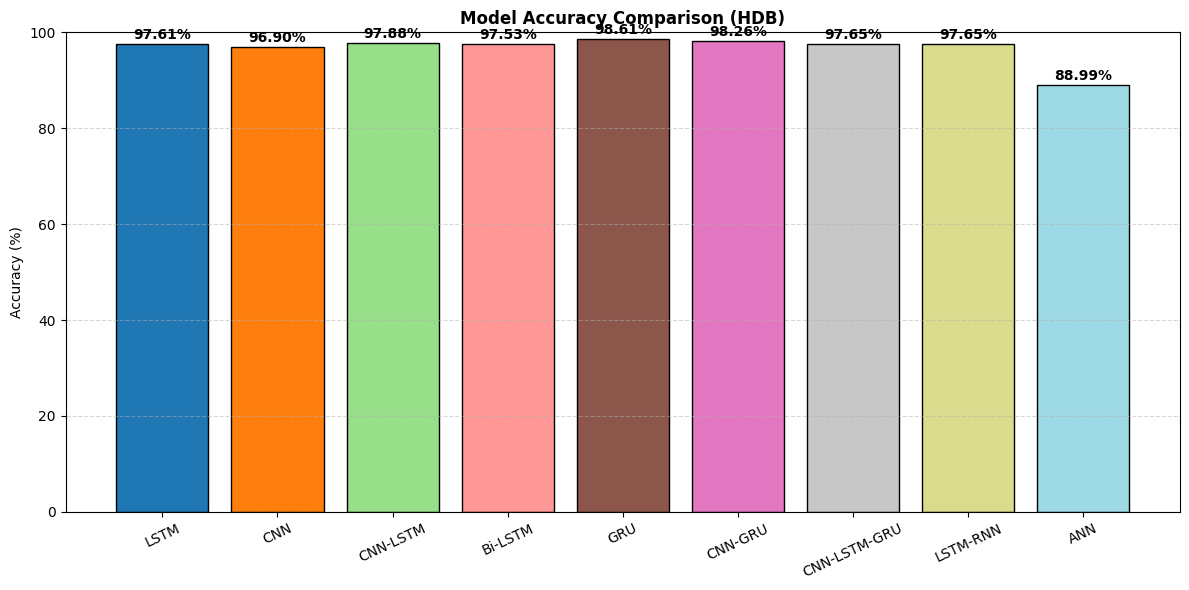

In [ ]:
# ======================================================
# 1. Imports & Setup
# ======================================================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU, Conv1D,
    MaxPooling1D, Flatten, Bidirectional
)

np.random.seed(42)
tf.random.set_seed(42)

# ======================================================
# 2. Load Stock Data
# ======================================================
stock = "HDB"
data = yf.download(stock, start="2015-01-01", end="2024-01-01")
data = data[['Close']].dropna()

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values)

# ======================================================
# 3. Create Sequences
# ======================================================
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

TIME_STEP = 60
X, y = create_dataset(scaled_data, TIME_STEP)

X_seq = X.reshape(X.shape[0], X.shape[1], 1)
X_flat = X

split = int(0.8 * len(X))
X_seq_train, X_seq_test = X_seq[:split], X_seq[split:]
X_flat_train, X_flat_test = X_flat[:split], X_flat[split:]
y_train, y_test = y[:split], y[split:]

actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# ======================================================
# 4. Regression Accuracy
# ======================================================
def regression_accuracy(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mean_true = np.mean(np.abs(y_true)) + 1e-8
    return (1 - mae / mean_true) * 100

# ======================================================
# 5. Model Builders
# ======================================================
def compile_train(model, Xtr, ytr):
    model.compile(optimizer='adam', loss='mse')
    model.fit(Xtr, ytr, epochs=10, batch_size=32, verbose=0)
    return model

models = {}

models["LSTM"] = compile_train(Sequential([
    LSTM(50, return_sequences=True, input_shape=(TIME_STEP,1)),
    LSTM(50), Dense(1)
]), X_seq_train, y_train)

models["CNN"] = compile_train(Sequential([
    Conv1D(64,3,activation='relu',input_shape=(TIME_STEP,1)),
    MaxPooling1D(2), Flatten(),
    Dense(50,activation='relu'), Dense(1)
]), X_seq_train, y_train)

models["CNN-LSTM"] = compile_train(Sequential([
    Conv1D(64,3,activation='relu',input_shape=(TIME_STEP,1)),
    MaxPooling1D(2), LSTM(50), Dense(1)
]), X_seq_train, y_train)

models["Bi-LSTM"] = compile_train(Sequential([
    Bidirectional(LSTM(50),input_shape=(TIME_STEP,1)),
    Dense(1)
]), X_seq_train, y_train)

models["GRU"] = compile_train(Sequential([
    GRU(50, return_sequences=True, input_shape=(TIME_STEP,1)),
    GRU(50), Dense(1)
]), X_seq_train, y_train)

models["CNN-GRU"] = compile_train(Sequential([
    Conv1D(64,3,activation='relu',input_shape=(TIME_STEP,1)),
    MaxPooling1D(2), GRU(50), Dense(1)
]), X_seq_train, y_train)

models["CNN-LSTM-GRU"] = compile_train(Sequential([
    Conv1D(64,3,activation='relu',input_shape=(TIME_STEP,1)),
    MaxPooling1D(2),
    LSTM(50, return_sequences=True),
    GRU(50), Dense(1)
]), X_seq_train, y_train)

models["LSTM-RNN"] = compile_train(Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEP,1)),
    Dropout(0.2), LSTM(64), Dense(1)
]), X_seq_train, y_train)

models["ANN"] = compile_train(Sequential([
    Dense(128,activation='relu',input_dim=TIME_STEP),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dense(1)
]), X_flat_train, y_train)

# ======================================================
# 6. Predictions
# ======================================================
preds = {}
for name, model in models.items():
    Xinput = X_flat_test if name=="ANN" else X_seq_test
    p = model.predict(Xinput)
    preds[name] = scaler.inverse_transform(p)

# ======================================================
# 7. Actual vs Predicted Plot
# ======================================================
plt.figure(figsize=(14,7))
plt.plot(actual, label="Actual", linewidth=2)

for name, p in preds.items():
    plt.plot(p, linestyle='dashed', label=name)

plt.title("Actual vs Predicted Stock Prices", fontweight='bold')
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(ncol=3)
plt.grid(True)
plt.tight_layout()
plt.show()

# ======================================================
# 8. Performance Table
# ======================================================
rows = []
accuracy = {}

for name, p in preds.items():
    mse = mean_squared_error(actual, p)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, p)
    acc = regression_accuracy(actual.ravel(), p.ravel())
    rows.append([name, mse, rmse, r2, acc])
    accuracy[name] = acc

df_perf = pd.DataFrame(rows, columns=[
    "Model","MSE","RMSE","R² Score","Accuracy (%)"
])

print("\nMODEL PERFORMANCE COMPARISON\n")
print(df_perf.sort_values("Accuracy (%)", ascending=False))

# ======================================================
# 9. Colorful Accuracy Bar Chart
# ======================================================
plt.figure(figsize=(12,6))
colors = plt.cm.tab20(np.linspace(0,1,len(accuracy)))

bars = plt.bar(accuracy.keys(), accuracy.values(),
               color=colors, edgecolor='black')

plt.ylabel("Accuracy (%)")
plt.title(f"Model Accuracy Comparison ({stock})", fontweight='bold')
plt.ylim(0,100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=25)

for b in bars:
    plt.text(b.get_x()+b.get_width()/2,
             b.get_height()+1,
             f"{b.get_height():.2f}%",
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


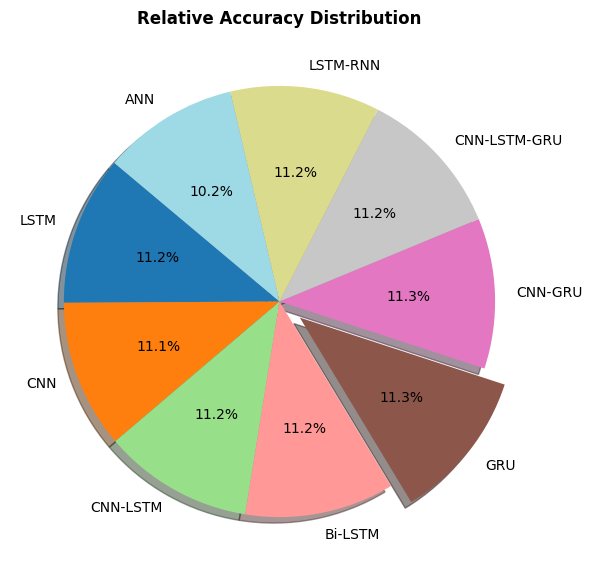

In [ ]:
plt.figure(figsize=(7,7))
colors = plt.cm.tab20(np.linspace(0,1,len(accuracy)))

explode = [0]*len(accuracy)
explode[np.argmax(list(accuracy.values()))] = 0.12

plt.pie(
    accuracy.values(),
    labels=accuracy.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True
)

plt.title("Relative Accuracy Distribution", fontweight='bold')
plt.show()


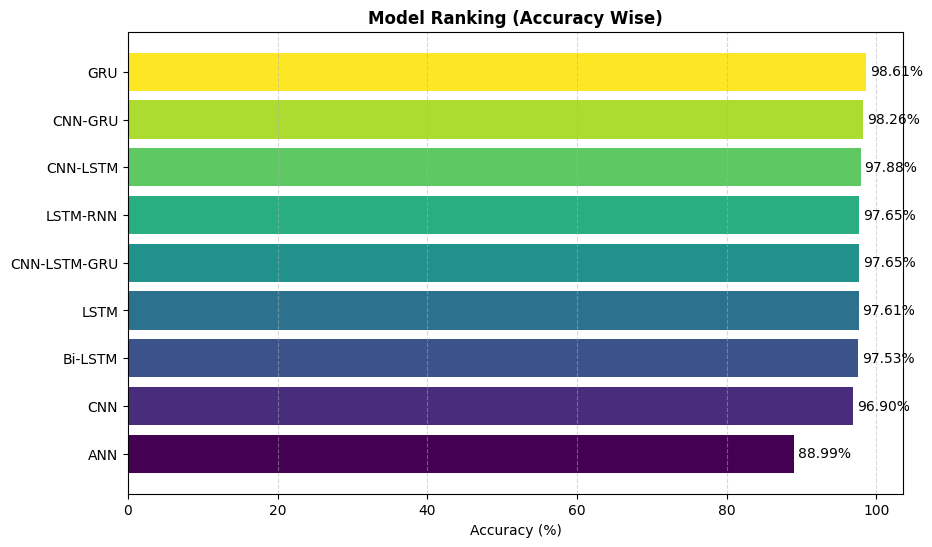

In [ ]:
sorted_acc = sorted(accuracy.items(), key=lambda x: x[1])

models = [x[0] for x in sorted_acc]
values = [x[1] for x in sorted_acc]

plt.figure(figsize=(10,6))
plt.barh(models, values, color=plt.cm.viridis(np.linspace(0,1,len(models))))

plt.xlabel("Accuracy (%)")
plt.title("Model Ranking (Accuracy Wise)", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(values):
    plt.text(v+0.5, i, f"{v:.2f}%", va='center')

plt.show()


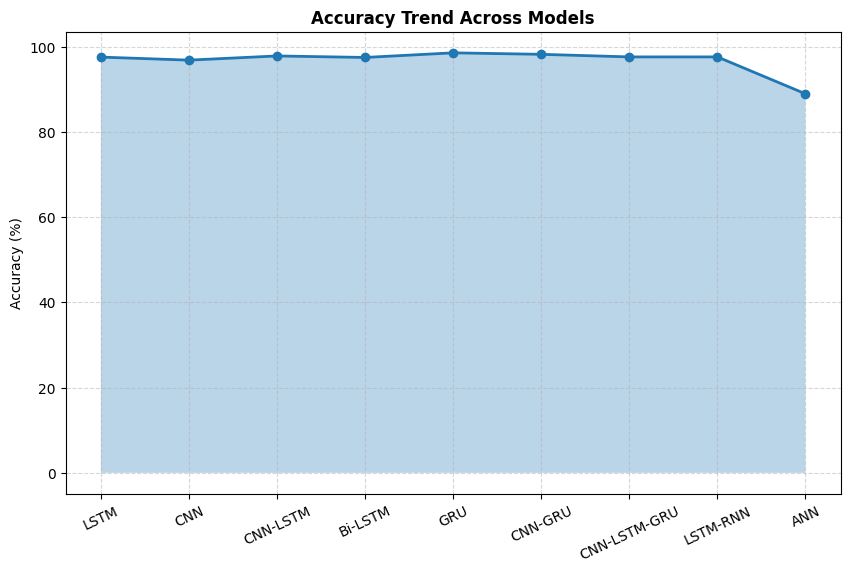

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(accuracy.keys(), accuracy.values(),
         marker='o', linewidth=2)

plt.fill_between(
    accuracy.keys(),
    accuracy.values(),
    alpha=0.3
)

plt.ylabel("Accuracy (%)")
plt.title("Accuracy Trend Across Models", fontweight='bold')
plt.xticks(rotation=25)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


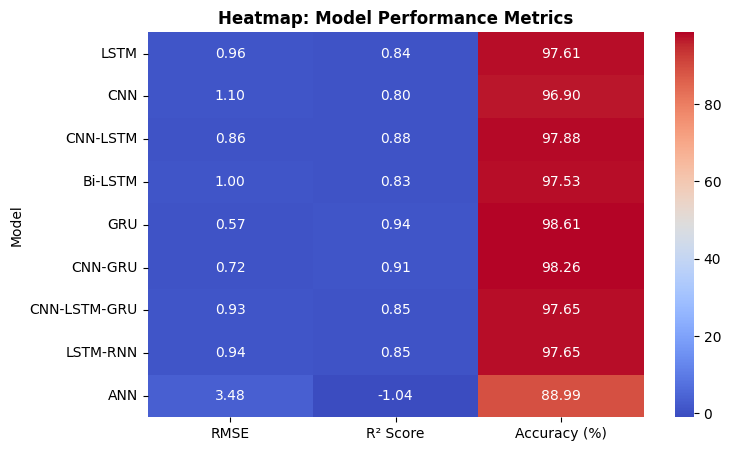

In [ ]:
import seaborn as sns

heat_data = df_perf.set_index("Model")[["RMSE","R² Score","Accuracy (%)"]]

plt.figure(figsize=(8,5))
sns.heatmap(heat_data, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap: Model Performance Metrics", fontweight='bold')
plt.show()


In [ ]:
gru_model.save("ai_stock_price_model.keras")